Parsing log file...
Successfully parsed 77 log entries



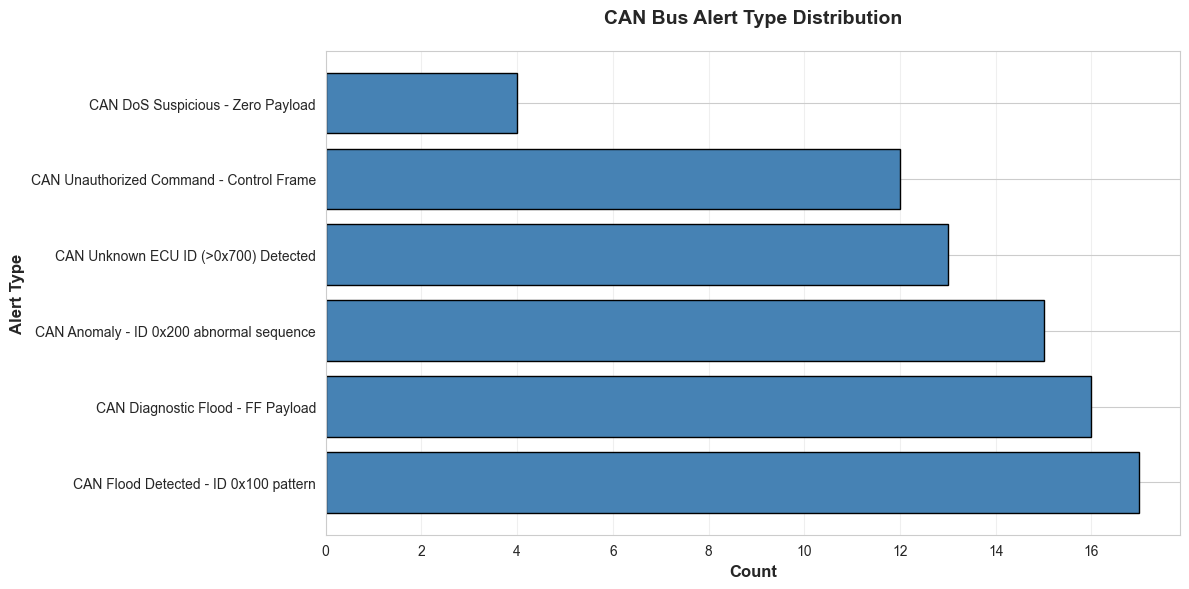

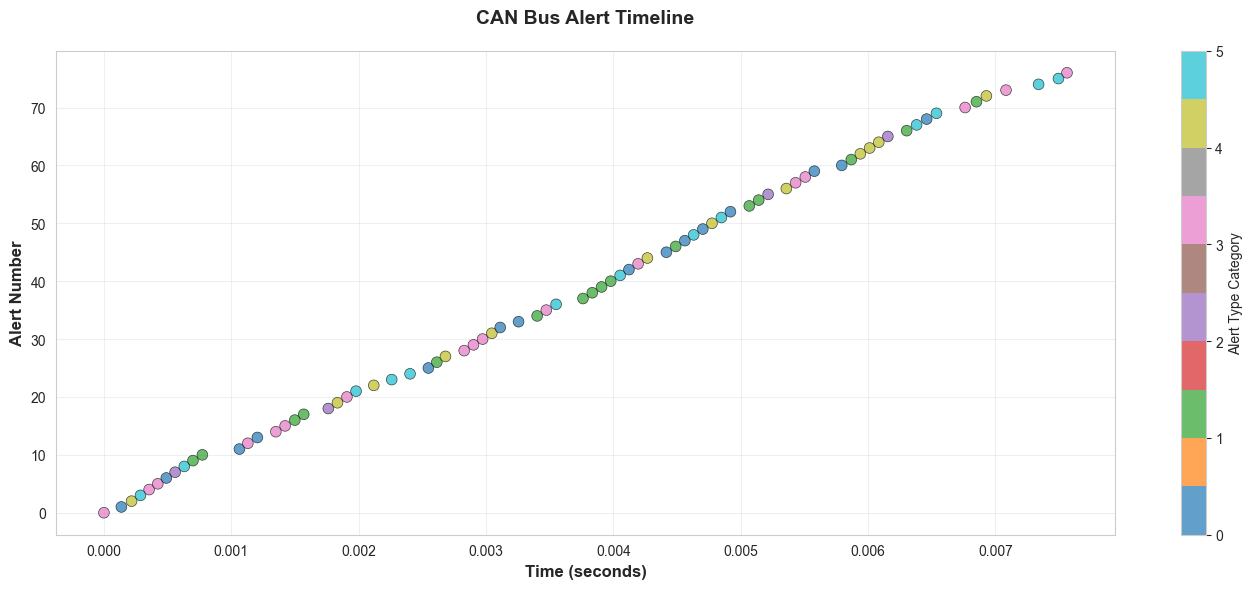

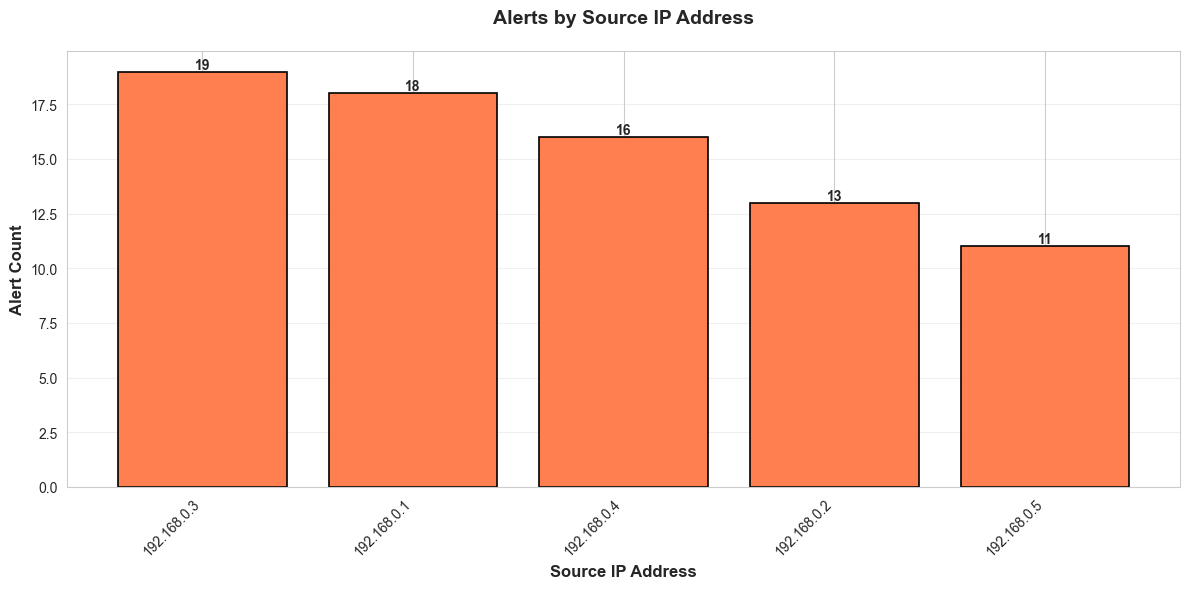

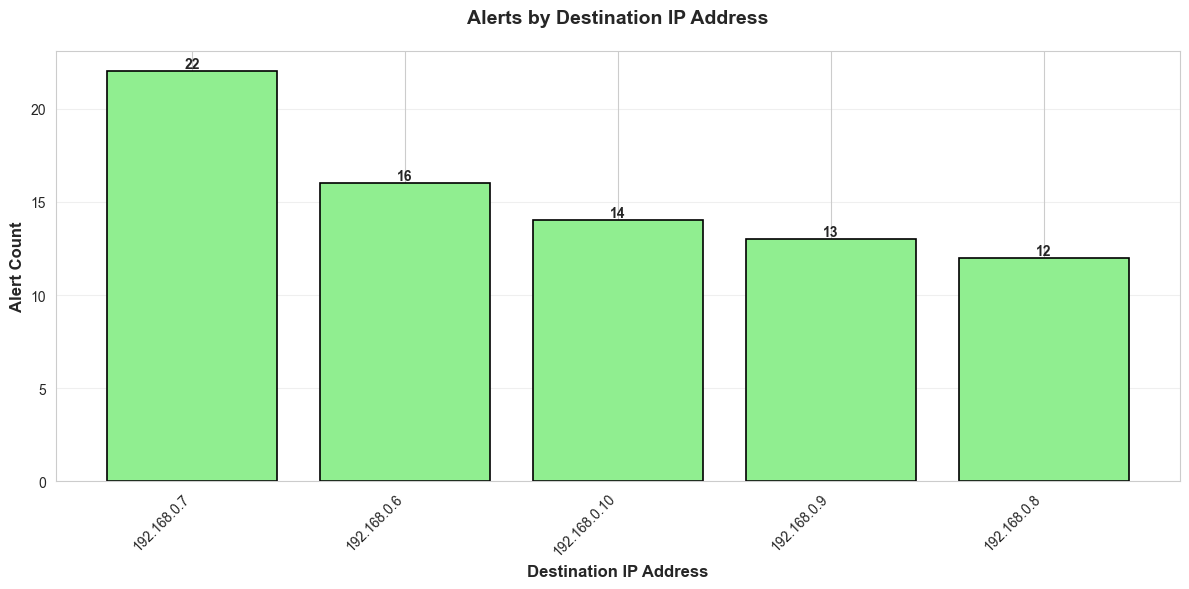

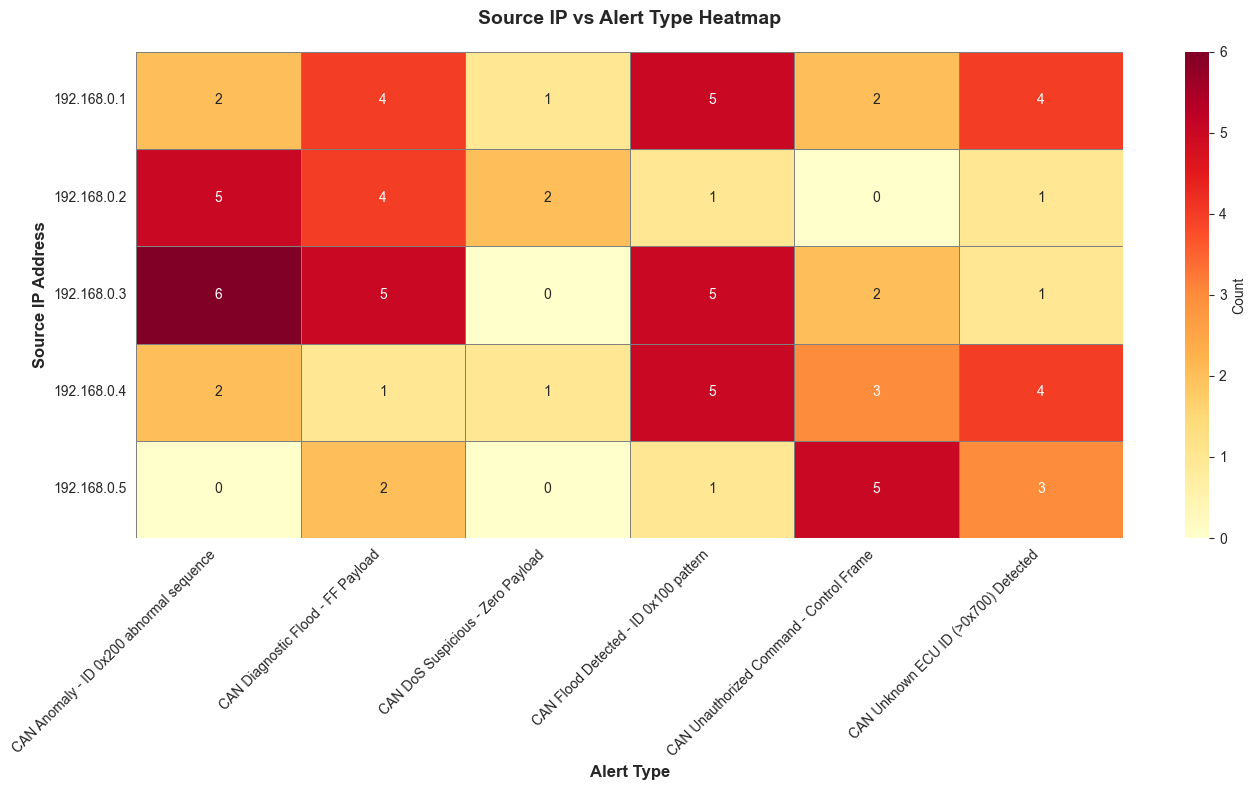

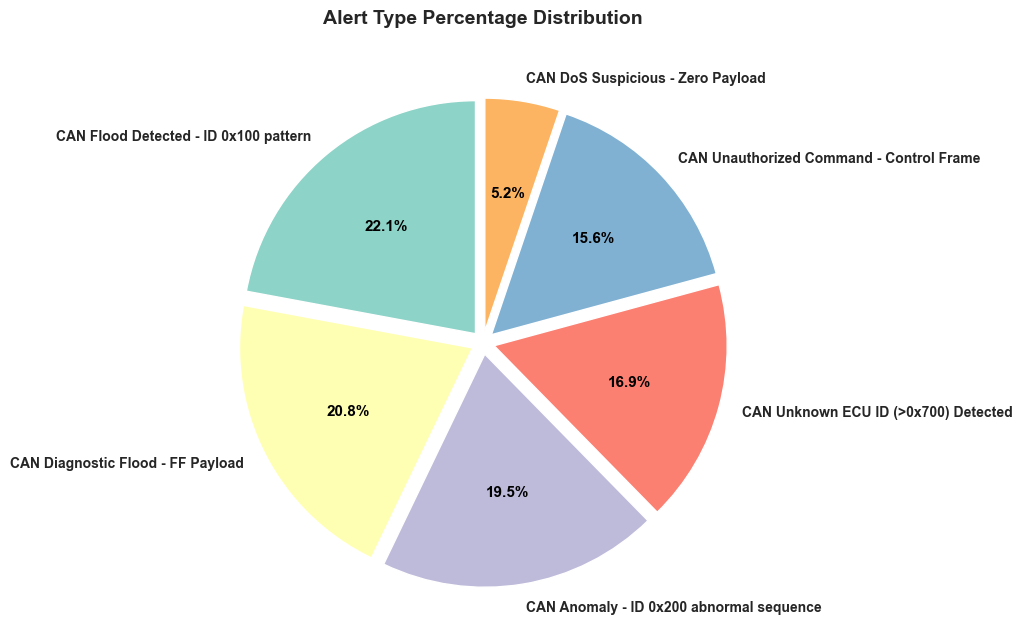

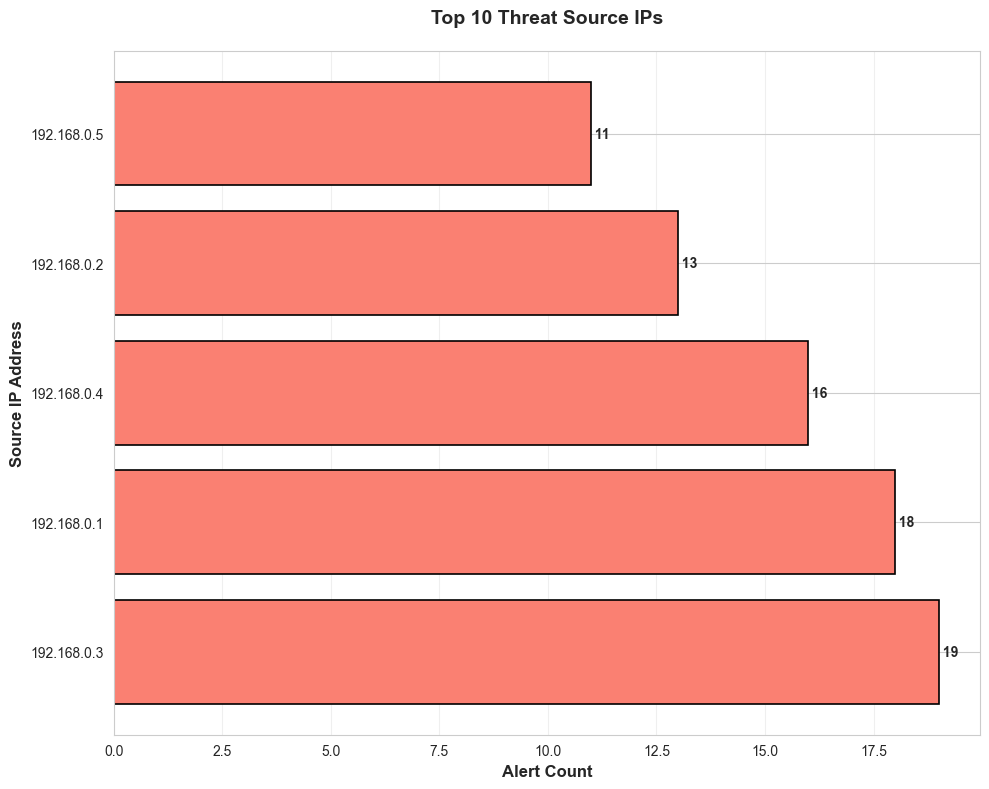


CAN BUS SECURITY LOG SUMMARY

Total Alerts: 77
Time Range: 2025-10-16 13:04:21.289475 to 2025-10-16 13:04:21.297038
Duration: 0.01 seconds

Unique Source IPs: 5
Unique Destination IPs: 5

TOP ALERT TYPES
CAN Flood Detected - ID 0x100 pattern: 17 (22.1%)
CAN Diagnostic Flood - FF Payload: 16 (20.8%)
CAN Anomaly - ID 0x200 abnormal sequence: 15 (19.5%)
CAN Unknown ECU ID (>0x700) Detected: 13 (16.9%)
CAN Unauthorized Command - Control Frame: 12 (15.6%)
CAN DoS Suspicious - Zero Payload: 4 (5.2%)

TOP THREAT SOURCES
192.168.0.3: 19 alerts (24.7%)
192.168.0.1: 18 alerts (23.4%)
192.168.0.4: 16 alerts (20.8%)
192.168.0.2: 13 alerts (16.9%)
192.168.0.5: 11 alerts (14.3%)

TOP TARGETED DESTINATIONS
192.168.0.7: 22 alerts (28.6%)
192.168.0.6: 16 alerts (20.8%)
192.168.0.10: 14 alerts (18.2%)
192.168.0.9: 13 alerts (16.9%)
192.168.0.8: 12 alerts (15.6%)

ATTACK PATTERNS BY SOURCE IP

192.168.0.3 (Total: 19 alerts):
  - CAN Anomaly - ID 0x200 abnormal sequence: 6 (31.6%)
  - CAN Flood Detected 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
from collections import Counter

# Read and parse the log file
def parse_log(file_path):
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            try:
                # Extract timestamp
                timestamp_match = re.search(r'(\d{2}/\d{2}/\d{4}-\d{2}:\d{2}:\d{2}\.\d+)', line)
                # Extract alert type - more flexible pattern
                alert_match = re.search(r'\[1:(\d+):\d+\] (.+?) \[\*\*\]', line)
                # Extract source and destination IPs
                ip_match = re.search(r'{UDP} ([\d.]+):(\d+) -> ([\d.]+):(\d+)', line)
                
                if timestamp_match and alert_match and ip_match:
                    data.append({
                        'timestamp': datetime.strptime(timestamp_match.group(1), '%m/%d/%Y-%H:%M:%S.%f'),
                        'rule_id': alert_match.group(1),
                        'alert_type': alert_match.group(2).strip(),
                        'src_ip': ip_match.group(1),
                        'src_port': int(ip_match.group(2)),
                        'dst_ip': ip_match.group(3),
                        'dst_port': int(ip_match.group(4))
                    })
            except Exception as e:
                print(f"Warning: Could not parse line: {line.strip()}")
                print(f"Error: {e}")
                continue
    
    if not data:
        raise ValueError("No data was parsed from the log file. Please check the file format.")
    
    return pd.DataFrame(data)

# Parse the log
print("Parsing log file...")
df = parse_log('../suricata_logs/fast.log')
print(f"Successfully parsed {len(df)} log entries\n")

# Set up the plotting style
sns.set_style("whitegrid")

# Calculate time in seconds for timeline
df['seconds'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds()

# Prepare data for visualizations
alert_counts = df['alert_type'].value_counts()
src_ip_counts = df['src_ip'].value_counts()
dst_ip_counts = df['dst_ip'].value_counts()

# ============================================================================
# VISUALIZATION 1: Alert Type Distribution
# ============================================================================
plt.figure(figsize=(12, 6))
plt.barh(alert_counts.index, alert_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('Count', fontsize=12, fontweight='bold')
plt.ylabel('Alert Type', fontsize=12, fontweight='bold')
plt.title('CAN Bus Alert Type Distribution', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 2: Alert Timeline
# ============================================================================
plt.figure(figsize=(14, 6))
scatter = plt.scatter(df['seconds'], df.index, c=pd.Categorical(df['alert_type']).codes, 
                      cmap='tab10', alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
plt.xlabel('Time (seconds)', fontsize=12, fontweight='bold')
plt.ylabel('Alert Number', fontsize=12, fontweight='bold')
plt.title('CAN Bus Alert Timeline', fontsize=14, fontweight='bold', pad=20)
plt.colorbar(scatter, label='Alert Type Category')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 3: Source IP Distribution
# ============================================================================
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(src_ip_counts)), src_ip_counts.values, color='coral', 
               edgecolor='black', linewidth=1.2)
plt.xticks(range(len(src_ip_counts)), src_ip_counts.index, rotation=45, ha='right')
plt.xlabel('Source IP Address', fontsize=12, fontweight='bold')
plt.ylabel('Alert Count', fontsize=12, fontweight='bold')
plt.title('Alerts by Source IP Address', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 4: Destination IP Distribution
# ============================================================================
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(dst_ip_counts)), dst_ip_counts.values, color='lightgreen', 
               edgecolor='black', linewidth=1.2)
plt.xticks(range(len(dst_ip_counts)), dst_ip_counts.index, rotation=45, ha='right')
plt.xlabel('Destination IP Address', fontsize=12, fontweight='bold')
plt.ylabel('Alert Count', fontsize=12, fontweight='bold')
plt.title('Alerts by Destination IP Address', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 5: Heatmap - Source IP vs Alert Type
# ============================================================================
plt.figure(figsize=(14, 8))
heatmap_data = pd.crosstab(df['src_ip'], df['alert_type'])
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', 
            linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Count'})
plt.title('Source IP vs Alert Type Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Alert Type', fontsize=12, fontweight='bold')
plt.ylabel('Source IP Address', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 6: Alert Type Pie Chart
# ============================================================================
plt.figure(figsize=(10, 10))
colors = plt.cm.Set3(range(len(alert_counts)))
wedges, texts, autotexts = plt.pie(alert_counts.values, labels=alert_counts.index, 
                                     autopct='%1.1f%%', colors=colors, startangle=90,
                                     textprops={'fontsize': 10, 'fontweight': 'bold'},
                                     explode=[0.05] * len(alert_counts))

# Make percentage text more readable
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

plt.title('Alert Type Percentage Distribution', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 7: Top Source IPs - Horizontal Bar Chart
# ============================================================================
plt.figure(figsize=(10, 8))
top_sources = src_ip_counts.head(10)
bars = plt.barh(range(len(top_sources)), top_sources.values, color='salmon', 
                edgecolor='black', linewidth=1.2)
plt.yticks(range(len(top_sources)), top_sources.index)
plt.xlabel('Alert Count', fontsize=12, fontweight='bold')
plt.ylabel('Source IP Address', fontsize=12, fontweight='bold')
plt.title('Top 10 Threat Source IPs', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2.,
             f' {int(width)}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================
print("\n" + "=" * 80)
print("CAN BUS SECURITY LOG SUMMARY")
print("=" * 80)
print(f"\nTotal Alerts: {len(df)}")
print(f"Time Range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Duration: {df['seconds'].max():.2f} seconds")
print(f"\nUnique Source IPs: {df['src_ip'].nunique()}")
print(f"Unique Destination IPs: {df['dst_ip'].nunique()}")

print("\n" + "=" * 80)
print("TOP ALERT TYPES")
print("=" * 80)
for alert_type, count in alert_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{alert_type}: {count} ({percentage:.1f}%)")

print("\n" + "=" * 80)
print("TOP THREAT SOURCES")
print("=" * 80)
for ip, count in src_ip_counts.head(5).items():
    percentage = (count / len(df)) * 100
    print(f"{ip}: {count} alerts ({percentage:.1f}%)")

print("\n" + "=" * 80)
print("TOP TARGETED DESTINATIONS")
print("=" * 80)
for ip, count in dst_ip_counts.head(5).items():
    percentage = (count / len(df)) * 100
    print(f"{ip}: {count} alerts ({percentage:.1f}%)")

# Additional analysis: Most common attack patterns
print("\n" + "=" * 80)
print("ATTACK PATTERNS BY SOURCE IP")
print("=" * 80)
for src_ip in src_ip_counts.head(3).index:
    alerts = df[df['src_ip'] == src_ip]['alert_type'].value_counts()
    print(f"\n{src_ip} (Total: {src_ip_counts[src_ip]} alerts):")
    for alert_type, count in alerts.items():
        percentage = (count / src_ip_counts[src_ip]) * 100
        print(f"  - {alert_type}: {count} ({percentage:.1f}%)")

print("\n" + "=" * 80)